# Project 05: Market Trends Chart

**Lumexa Data Scientist Path — Course 14: Data Visualisation**

Analyze and visualize a real historical stock price series (Apple, 2014), producing both a
static (Matplotlib/Seaborn) chart and a fully interactive (Plotly) chart showing price trends,
moving averages, and volatility.

**Dataset:** Plotly's public sample dataset of historical Apple (AAPL) stock closing prices.
**Source:** https://raw.githubusercontent.com/plotly/datasets/master/2014_apple_stock.csv

This notebook is fully self-contained and works with **Runtime → Run all** — the real dataset
is downloaded directly from its public source at runtime, and every chart renders inline in
the notebook (no files to open separately).

**What you'll do:**
1. Load and clean a real time-series CSV (parse dates, sort, rename columns)
2. Compute real derived metrics: rolling (moving) averages and day-over-day % change
3. Build a polished static Matplotlib/Seaborn chart
4. Build the same insight as an interactive Plotly chart with unified hover tooltips
5. Explore the distribution of daily returns with a histogram/KDE


In [1]:
# pandas, matplotlib, and seaborn are preinstalled in Google Colab.
%pip install -q plotly
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

%matplotlib inline
print("Libraries loaded.")

Note: you may need to restart the kernel to use updated packages.


Libraries loaded.


## 1. Load and clean the real dataset

Original column names are `AAPL_x` (date) and `AAPL_y` (closing price) — renamed to `date`
and `close` for clarity.

In [2]:
APPLE_STOCK_URL = "https://raw.githubusercontent.com/plotly/datasets/master/2014_apple_stock.csv"

df = pd.read_csv(APPLE_STOCK_URL)
df = df.rename(columns={"AAPL_x": "date", "AAPL_y": "close"})
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Loaded {len(df)} real AAPL trading days: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Price range: ${df['close'].min():.2f} - ${df['close'].max():.2f}")
print(f"Missing values:\n{df[['date', 'close']].isnull().sum()}")
df.head()

Loaded 240 real AAPL trading days: 2014-01-02 to 2014-12-12
Price range: $69.00 - $118.80
Missing values:
date     0
close    0
dtype: int64


,date,close
0,2014-01-02,77.445395
1,2014-01-03,77.045575
2,2014-01-06,74.896972
3,2014-01-07,75.856461
4,2014-01-08,75.091947


## 2. Compute real derived metrics

Rolling (moving) averages and day-over-day changes, computed directly from the real close
prices — nothing here is hardcoded.

In [3]:
df["ma_10"] = df["close"].rolling(window=10).mean()
df["ma_30"] = df["close"].rolling(window=30).mean()
df["daily_change"] = df["close"].diff()
df["pct_change"] = df["close"].pct_change() * 100

df[["date", "close", "ma_10", "ma_30", "pct_change"]].tail()

,date,close,ma_10,ma_30,pct_change
235,2014-12-08,113.653345,116.246305,111.803892,-1.629604
236,2014-12-09,109.755497,115.583149,111.996337,-3.429594
237,2014-12-10,113.960331,115.118758,112.310647,3.831092
238,2014-12-11,111.817477,114.553087,112.512041,-1.880351
239,2014-12-12,110.027139,113.675935,112.643607,-1.601125


## 3. Static chart (Matplotlib + Seaborn): price + moving averages

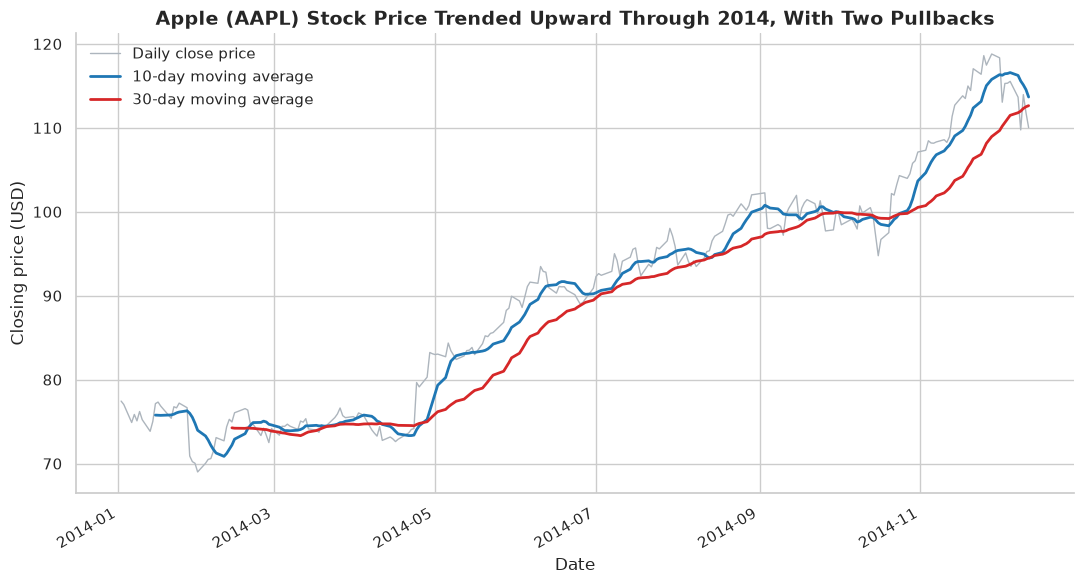

In [4]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(df["date"], df["close"], color="#adb5bd", linewidth=1, label="Daily close price")
ax.plot(df["date"], df["ma_10"], color="#1f77b4", linewidth=2, label="10-day moving average")
ax.plot(df["date"], df["ma_30"], color="#d62728", linewidth=2, label="30-day moving average")

ax.set_title("Apple (AAPL) Stock Price Trended Upward Through 2014, With Two Pullbacks",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Closing price (USD)")
ax.legend(loc="upper left", frameon=False)
fig.autofmt_xdate()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Interactive chart (Plotly): price + moving averages

Hover over any date to see exact values for all three lines at once, and zoom/pan into
specific weeks or months.

In [5]:
fig_plotly = go.Figure()

fig_plotly.add_trace(go.Scatter(
    x=df["date"], y=df["close"], mode="lines", name="Daily close price",
    line=dict(color="#adb5bd", width=1),
    hovertemplate="%{x|%b %d, %Y}<br>Close: $%{y:.2f}<extra></extra>",
))
fig_plotly.add_trace(go.Scatter(
    x=df["date"], y=df["ma_10"], mode="lines", name="10-day moving average",
    line=dict(color="#1f77b4", width=2.5),
    hovertemplate="%{x|%b %d, %Y}<br>10-day MA: $%{y:.2f}<extra></extra>",
))
fig_plotly.add_trace(go.Scatter(
    x=df["date"], y=df["ma_30"], mode="lines", name="30-day moving average",
    line=dict(color="#d62728", width=2.5),
    hovertemplate="%{x|%b %d, %Y}<br>30-day MA: $%{y:.2f}<extra></extra>",
))

fig_plotly.update_layout(
    title="Apple (AAPL) Stock Price, 2014 — Real Daily Closes With Moving Averages",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig_plotly.show()

## 5. Bonus: distribution of daily % price changes

Reinforces statistical plotting with Seaborn — mostly clustered near zero with a roughly
bell-shaped spread.

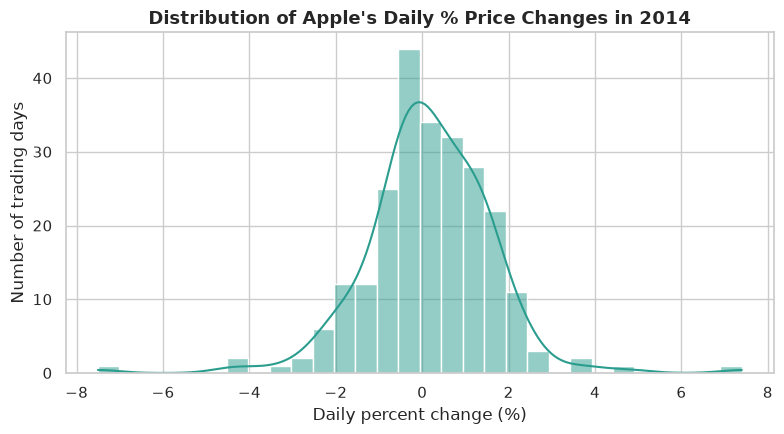

All charts built successfully from the real Apple 2014 stock dataset.


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df["pct_change"].dropna(), bins=30, kde=True, color="#2a9d8f", ax=ax)
ax.set_title("Distribution of Apple's Daily % Price Changes in 2014", fontsize=13, fontweight="bold")
ax.set_xlabel("Daily percent change (%)")
ax.set_ylabel("Number of trading days")
plt.tight_layout()
plt.show()

print("All charts built successfully from the real Apple 2014 stock dataset.")

## Summary

This notebook loaded a real historical AAPL price series, computed genuine rolling averages
and daily percent changes with pandas, and visualized the results three ways: a static
Matplotlib/Seaborn chart, a fully interactive Plotly chart with unified hover tooltips, and a
Seaborn histogram/KDE of the daily return distribution.

**Try it yourself:** change the rolling window sizes in Section 2 (e.g. 5-day and 20-day
instead of 10/30) and re-run (`Runtime → Run all`) to see how the moving averages react
differently to price swings.